In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from pathlib import Path
import seaborn as sns 
import matplotlib as mpl
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

In [ ]:
# Import data 
        # This is where you will define filelst and filenames
parent_folder = Path(r"C...") # UPDATE FOR YOUR FILE PATH
filelst = list(parent_folder.glob("*.csv"))
filenames = [f.name for f in filelst]

# Read each file into a data frame
data_dict = {}
for i in range(len(filelst)):
    data_dict[filenames[i]] = pd.read_csv(filelst[i])


DATA PROCESSING AND CLEANUP

In [27]:
## REQUIRED PREPROCESSING BEFORE RUNNING BELOW: 

# for each experiment, compute "tc-t" and "d/d0, mm".
d0 = 6 # mm (plate diameter)

# eg below
for f in filenames[:]:
    data_dict[f]["d/d0, mm"] = data_dict[f]["diameter_mm"]/d0  # computing true d/do
    data_dict[f]["tbreak - t"] = data_dict[f]["time_ms"].iloc[-1] - data_dict[f]["time_ms"]# Computing tbreak - t, which is the time delta between breakage and the current time point.



In [28]:
# list of unique experimental conditions
expts:list = ["05p", "1p", "2p"]
# print(expts)

# dictionary with list of filenames associated with a given experimental condition(the triplicate filenames)
org_expts = {}  # DICTIONARY OF FILENEAMES and EXPERIMENTAL CONDITIONS. Used to access the data frames associated with each experimental condition, 
                # which are stored in data_dict with key = filename.
for expt in expts:
    print(expt)
    n_lst = []
    for f in filenames:   # Finding the triplicate files associated with each experimental condition, then appending to list
        if expt in f:
            n_lst.append(f)
    print(n_lst)
    org_expts.update({expt: n_lst})   # adding to dictionary with key = expt, value = list of associated filenames

data_dict[org_expts[expts[2]][2]]

05p
['05pcent_HA_1.csv', '05pcent_HA_2.csv', '05pcent_HA_3.csv']
1p
['1pcent_HA_1.csv', '1pcent_HA_2.csv', '1pcent_HA_3.csv']
2p
['2pcent_HA_1.csv', '2pcent_HA_2.csv', '2pcent_HA_3.csv']


,time_ms,diameter_mm,"d/d0, mm",tbreak - t
0,0.0,2.580,0.430000,1645.0
1,1.0,2.537,0.422833,1644.0
2,2.0,2.537,0.422833,1643.0
3,3.0,2.537,0.422833,1642.0
4,4.0,2.537,0.422833,1641.0
...,...,...,...,...
1641,1641.0,0.086,0.014333,4.0
1642,1642.0,0.086,0.014333,3.0
1643,1643.0,0.086,0.014333,2.0
1644,1644.0,0.043,0.007167,1.0


In [30]:
# Averaging the data - new, relevant data.
# Compiling data: tbreak-t, d,mm and d/d0. aligning the data based on tbreak-t instead of expt_time.
# Assembling all into a dictionary with key = expt, value = dataframe with the relevant columns from the triplicates concatenated together.

averaged_tbreak_aligned = {} 
for expt in expts:
    # Sort each data frame by tbreak-t. mask gets rid of any NaN values in d_mm column
    df_1 = data_dict[org_expts[expt][0]].sort_values(by="tbreak - t").reset_index(drop = True)
    mask_1 = df_1["diameter_mm"].notna()
    df_2 = data_dict[org_expts[expt][1]].sort_values(by="tbreak - t").reset_index(drop = True)
    mask_2 = df_2["diameter_mm"].notna()
    df_3 = data_dict[org_expts[expt][2]].sort_values(by="tbreak - t").reset_index(drop = True)
    mask_3 = df_3["diameter_mm"].notna()
    # combining the aligned data frames into a single data frame, and adding to dictionary with key = expt, value = combined data frame
    averaged_tbreak_aligned.update({expt: pd.concat([df_1[["tbreak - t", "diameter_mm","d/d0, mm"]][mask_1],
                                                      df_2[["tbreak - t", "diameter_mm","d/d0, mm"]][mask_2],
                                                      df_3[["tbreak - t", "diameter_mm","d/d0, mm"]][mask_3]], axis = 1)})
    
# averaged_tbreak_aligned[expts[0]].tail(20)

#averaging
for expt in expts:
    averaged_tbreak_aligned[expt]["avg_tc-t"] = averaged_tbreak_aligned[expt].iloc[:, [0,3,6]].mean(axis = 1)
    averaged_tbreak_aligned[expt]["std_tc-t"] = averaged_tbreak_aligned[expt].iloc[:, [0,3,6]].std(axis = 1)
    averaged_tbreak_aligned[expt]["avg_d, mm"] = averaged_tbreak_aligned[expt].iloc[:, [1,4,7]].mean(axis = 1)
    averaged_tbreak_aligned[expt]["std_d, mm"] = averaged_tbreak_aligned[expt].iloc[:, [1,4,7]].std(axis = 1)
    averaged_tbreak_aligned[expt]["avg_d/d0, mm"] = averaged_tbreak_aligned[expt].iloc[:, [2,5,8]].mean(axis = 1)
    averaged_tbreak_aligned[expt]["std_d/d0, mm"] = averaged_tbreak_aligned[expt].iloc[:, [2,5,8]].std(axis = 1)


averaged_tbreak_aligned[expts[1]]


,tbreak - t,diameter_mm,"d/d0, mm",tbreak - t,diameter_mm,"d/d0, mm",tbreak - t,diameter_mm,"d/d0, mm",avg_tc-t,std_tc-t,"avg_d, mm","std_d, mm","avg_d/d0, mm","std_d/d0, mm"
0,0.0,0.000,0.000000,0.0,0.000,0.000000,0.0,0.000,0.000000,0.0,0.0,0.000000,0.000000e+00,0.000000,0.000000
1,1.0,0.043,0.007167,1.0,0.043,0.007167,1.0,0.043,0.007167,1.0,0.0,0.043000,8.498375e-18,0.007167,0.000000
2,2.0,0.043,0.007167,2.0,0.043,0.007167,2.0,0.086,0.014333,2.0,0.0,0.057333,2.482606e-02,0.009556,0.004138
3,3.0,0.086,0.014333,3.0,0.086,0.014333,3.0,0.086,0.014333,3.0,0.0,0.086000,1.699675e-17,0.014333,0.000000
4,4.0,0.086,0.014333,4.0,0.086,0.014333,4.0,0.086,0.014333,4.0,0.0,0.086000,1.699675e-17,0.014333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,NaN,NaN,NaN,NaN,NaN,NaN,184.0,2.064,0.344000,184.0,NaN,2.064000,NaN,0.344000,NaN
185,NaN,NaN,NaN,NaN,NaN,NaN,185.0,2.064,0.344000,185.0,NaN,2.064000,NaN,0.344000,NaN
186,NaN,NaN,NaN,NaN,NaN,NaN,186.0,2.064,0.344000,186.0,NaN,2.064000,NaN,0.344000,NaN
187,NaN,NaN,NaN,NaN,NaN,NaN,187.0,2.107,0.351167,187.0,NaN,2.107000,NaN,0.351167,NaN


HYALURONIC ACID-----------------------------------------

0.5%HA: r-square = 0.9833748489933782 tao = 4.1451989481891705 +/- 0.572273910663985
1%HA: r-square = 0.9905166124152319 tao = 47.26152872500915 +/- 1.4986848386624259
2%HA: r-square = 0.9903134370361024 tao = 573.7911234369107 +/- 52.39456396537727


(-4.0, -0.8)

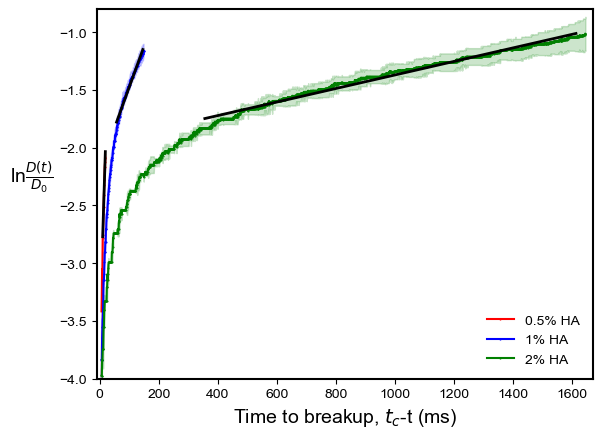

In [31]:

# Setting font
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

# setting line width
plt.rcParams['axes.linewidth'] = 1.5

# Figure colours setup
run_colours = {expts[0]: "red", 
            expts[1]: "blue",
            expts[2]: "green"}

# Legend names setup
label_names = {expts[0]: "0.5% HA", 
            expts[1]: "1% HA",
            expts[2]: "2% HA"}


fig, ax = plt.subplots()

# Goal: calculate relaxation time, and generate graph - this is a very ineffecient way, and could work for small data sets! 

# Relevant equation: D(t)/D0 proportional to Ae^(-t/3*relaxation time -> ln(D(t)/D0)) = -t/3*relaxation time
# To calculate, want: slope of log/linear plot of D(t)/D0 vs (tc-t). Slope = 1/3*relaxation time --> relaxation time = 1/3*slope
## 1. Calculate ln(D(t)/D0) for each experiment

relax_expts = {} # dictionary to manage the dataframes with relevant data for relaxation time 
for i in range(3): # Going through each relevant experiment
# i = 0 # 0.5% HA
    df = averaged_tbreak_aligned[expts[i]]
    # column selection
    t_cols = [0, 3, 6] # columns corresponding to tc-t for each replicate
    d_cols = [2, 5, 8] # columns corresponding to d/do for each replicate
    for c in d_cols[:]: 
        df[f"ln(d/d0)_{d_cols.index(c)+1}"] = np.log(df.iloc[1:, c]) # caclulating lnd/do. each column has new title lnd/do_1 to lnd/do_3
    df["avgln(d/d0)"] = df.iloc[:, [15,16,17]].mean(axis=1) # mean of the ln(d/do)
    df["stdln(d/d0)"] = df.iloc[:, [15,16,17]].std(axis=1)  # standard deviation of ln(d/do)

    relax_df = df.iloc[:, [9,15,16,17,18, 19]].dropna() # Only keep data frame 
    relax_expts.update({expts[i]: relax_df})

### ----------- NEED TO DO FOR EACH DATA SET FROM HERE ON ---------------
# # 2. Determine linear region via second derivative analysis - using average 
i = 0 # 0.5% HA
# for i in range(3):
relax_df = relax_expts[expts[i]]
smooth_window = 7
relax_df["smooth_avglnd/do"] = savgol_filter(relax_df["avgln(d/d0)"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d1"] = np.gradient(relax_df["smooth_avglnd/do"], relax_df["avg_tc-t"]) # find first derivative
relax_df["smooth_d1"] = savgol_filter(relax_df["d1"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d2"] = np.gradient(relax_df["smooth_d1"], relax_df["avg_tc-t"]) # find second derivative


## 3. Determine linear region of log/linear plot ---> corresponds to exponential region of linear/linear plot
# find when d2 = 0 (i.e. <0.01)
mask = np.abs(relax_df["d2"].values[:]) < 0.015 # this helps identifiy the regions
start = relax_df["avg_tc-t"][mask].index[0] # find starting index for linear regression
end = relax_df["avg_tc-t"][mask].index[-1] # find final index for linear regression
## 4. Fit line (do linear regression) and extract slope on each individual dataset, and calculat relaxation time:
reps = 3
regr_data = [] # list of tuples with slope, intercept, r^2 
rel_times = [] # list of relaxation times 
for c in range(1,reps+1):
    slope, intercept, r_value, p_value, stderr = linregress(relax_df.iloc[:, 0].values[start:end], relax_df.iloc[:, c].values[start:end]) #ms
    regr_data.append((slope, intercept, r_value))
    rel_times.append(1/(3*slope))

avg_relax_t_05HA = sum(rel_times)/reps
stdev_relax_t_05HA= np.std(rel_times)
print("0.5%HA:", "r-square =", (regr_data[0][2]+ regr_data[1][2] + regr_data[2][2])/3, "tao =", avg_relax_t_05HA, "+/-", stdev_relax_t_05HA)


ax.plot(relax_df["avg_tc-t"][5:], relax_df["avgln(d/d0)"][5:], 
        color = run_colours[expts[i]], label = label_names[expts[i]], marker = "o", markersize = 0.5, linestyle = "-")
ax.fill_between(relax_df["avg_tc-t"], 
                relax_df["avgln(d/d0)"] + relax_df["stdln(d/d0)"], 
                relax_df["avgln(d/d0)"] - relax_df["stdln(d/d0)"], 
                alpha = 0.2, color = run_colours[expts[i]])
# ax.plot(relax_df["avg_tc-t"][start:end], relax_df["smooth_avglnd/do"][start:end])
# ax.plot(relax_df["avg_tc-t"], relax_df["d1"])
# ax.plot(relax_df["avg_tc-t"], relax_df["d2"])
avg_slope = (regr_data[0][0]+ regr_data[1][0] + regr_data[2][0])/3
avg_int = (regr_data[0][1]+ regr_data[1][1] + regr_data[2][1])/3
ax.plot(relax_df["avg_tc-t"][start:end], avg_slope*relax_df["avg_tc-t"][start:end] + avg_int, 
        color='black', linestyle='-', linewidth=2)

#----------------------------------------------------------------------------------------------------------------------------#
i = 1 # 1% HA

relax_df = relax_expts[expts[i]]
smooth_window = 17
relax_df["smooth_avglnd/do"] = savgol_filter(relax_df["avgln(d/d0)"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d1"] = np.gradient(relax_df["smooth_avglnd/do"], relax_df["avg_tc-t"]) # find first derivative
relax_df["smooth_d1"] = savgol_filter(relax_df["d1"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d2"] = np.gradient(relax_df["smooth_d1"], relax_df["avg_tc-t"]) # find second derivative


## 3. Determine linear region of log/linear plot ---> corresponds to exponential region of linear/linear plot
# find when d2 = 0 (i.e. <0.01)
mask = np.abs(relax_df["d2"].values[:]) < 0.00015 # this helps identifiy the regions
start = relax_df["avg_tc-t"][mask].index[0] # find starting index for linear regression
end = relax_df["avg_tc-t"][mask].index[-1] # find final index for linear regression
## 4. Fit line (do linear regression) and extract slope on each individual dataset, and calculat relaxation time:
reps = 3
regr_data = [] # list of tuples with slope, intercept, r^2 
rel_times = [] # list of relaxation times 
for c in range(1,reps+1):
    slope, intercept, r_value, p_value, stderr = linregress(relax_df.iloc[:, 0].values[start:end], relax_df.iloc[:, c].values[start:end]) #ms
    regr_data.append((slope, intercept, r_value))
    rel_times.append(1/(3*slope))
avg_relax_t_1HA = sum(rel_times)/reps
stdev_relax_t_1HA= np.std(rel_times)
print("1%HA:", "r-square =", (regr_data[0][2]+ regr_data[1][2] + regr_data[2][2])/3, "tao =", avg_relax_t_1HA, "+/-", stdev_relax_t_1HA)

        # plotting
ax.plot(relax_df["avg_tc-t"][5:], relax_df["avgln(d/d0)"][5:], 
        color = run_colours[expts[i]], label = label_names[expts[i]], marker = "o", markersize = 0.5, linestyle = "-")
ax.fill_between(relax_df["avg_tc-t"], 
                relax_df["avgln(d/d0)"] + relax_df["stdln(d/d0)"], 
                relax_df["avgln(d/d0)"] - relax_df["stdln(d/d0)"], 
                alpha = 0.2, color = run_colours[expts[i]])

avg_slope = (regr_data[0][0]+ regr_data[1][0] + regr_data[2][0])/3
avg_int = (regr_data[0][1]+ regr_data[1][1] + regr_data[2][1])/3
ax.plot(relax_df["avg_tc-t"][start:end], avg_slope*relax_df["avg_tc-t"][start:end] + avg_int, 
        color='black', linestyle='-', linewidth=2)


#----------------------------------------------------------------------------------------------------------------------------#
i = 2 # 2% HA

relax_df = relax_expts[expts[i]]
smooth_window = 51
relax_df["smooth_avglnd/do"] = savgol_filter(relax_df["avgln(d/d0)"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d1"] = np.gradient(relax_df["smooth_avglnd/do"], relax_df["avg_tc-t"]) # find first derivative
relax_df["smooth_d1"] = savgol_filter(relax_df["d1"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d2"] = np.gradient(relax_df["smooth_d1"], relax_df["avg_tc-t"]) # find second derivative


## 3. Determine linear region of log/linear plot ---> corresponds to exponential region of linear/linear plot
# find when d2 = 0 (i.e. <0.01)
mask = np.abs(relax_df["d2"].values[:]) < 0.0000009 # this helps identifiy the regions
start = relax_df["avg_tc-t"][mask].index[0] # find starting index for linear regression
end = relax_df["avg_tc-t"][mask].index[-1] # find final index for linear regression
## 4. Fit line (do linear regression) and extract slope on each individual dataset, and calculat relaxation time:
reps = 3
regr_data = [] # list of tuples with slope, intercept, r^2 
rel_times = [] # list of relaxation times 
for c in range(1,reps+1):
    slope, intercept, r_value, p_value, stderr = linregress(relax_df.iloc[:, 0].values[start:end], relax_df.iloc[:, c].values[start:end]) #ms
    regr_data.append((slope, intercept, r_value))
    rel_times.append(1/(3*slope))
avg_relax_t_2HA = sum(rel_times)/reps
stdev_relax_t_2HA= np.std(rel_times)
print("2%HA:", "r-square =", (regr_data[0][2]+ regr_data[1][2] + regr_data[2][2])/3, "tao =", avg_relax_t_2HA, "+/-", stdev_relax_t_2HA)

        # plotting
ax.plot(relax_df["avg_tc-t"][5:], relax_df["avgln(d/d0)"][5:], 
        color = run_colours[expts[i]], label = label_names[expts[i]], marker = "o", markersize = 0.5, linestyle = "-")
ax.fill_between(relax_df["avg_tc-t"][5:], 
                relax_df["avgln(d/d0)"][5:] + relax_df["stdln(d/d0)"][5:], 
                relax_df["avgln(d/d0)"][5:] - relax_df["stdln(d/d0)"][5:], 
                alpha = 0.2, color = run_colours[expts[i]])

avg_slope = (regr_data[0][0]+ regr_data[1][0] + regr_data[2][0])/3
avg_int = (regr_data[0][1]+ regr_data[1][1] + regr_data[2][1])/3
ax.plot(relax_df["avg_tc-t"][start:end], avg_slope*relax_df["avg_tc-t"][start:end] + avg_int, 
        color='black', linestyle='-', linewidth=2)



ax.set_xlabel(r"Time to breakup, $t_c$-t (ms)", fontsize = 14)
ax.set_ylabel(r"ln$\frac{D(t)}{D_0}$", fontsize = 14, rotation = 0, labelpad=20, ha = "center")
ax.legend(frameon = False)
# plt.xscale("log")
plt.xlim(-10, 1670)
plt.ylim(-4, -0.8)


# plt.savefig(fr"{parent_folder}\HA_concentrations.png", dpi=300, bbox_inches='tight', transparent = True) 


[np.float64(31.94787421201396), np.float64(15.769168230019828), np.float64(304.5010490768281)]
[np.float64(45.0), np.float64(171.0), np.float64(2052.3333333333335)]


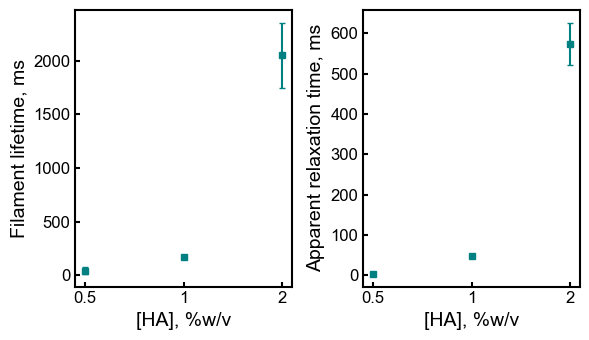

In [35]:
x_vals = ["0.5", "1", "2"]
y_vals = [avg_relax_t_05HA, avg_relax_t_1HA, avg_relax_t_2HA]
y_std = [stdev_relax_t_05HA, stdev_relax_t_1HA, stdev_relax_t_2HA]

y_tbr = [(data_dict[org_expts[expts[0]][0]].iloc[:, 0].values[-1]+ data_dict[org_expts[expts[0]][1]].iloc[:, 0].values[-1]+ data_dict[org_expts[expts[0]][2]].iloc[:, 0].values[-1])/3,
         (data_dict[org_expts[expts[1]][0]].iloc[:, 0].values[-1]+ data_dict[org_expts[expts[1]][1]].iloc[:, 0].values[-1]+ data_dict[org_expts[expts[1]][2]].iloc[:, 0].values[-1])/3,
         (data_dict[org_expts[expts[2]][0]].iloc[:, 0].values[-1]+ data_dict[org_expts[expts[2]][1]].iloc[:, 0].values[-1]+ data_dict[org_expts[expts[2]][2]].iloc[:, 0].values[-1])/3]
y_tbr_std = [np.std([data_dict[org_expts[expts[0]][0]].iloc[:, 0].values[-1], data_dict[org_expts[expts[0]][1]].iloc[:, 0].values[-1],  data_dict[org_expts[expts[0]][2]].iloc[:, 0].values[-1]]),
             np.std([data_dict[org_expts[expts[1]][0]].iloc[:, 0].values[-1], data_dict[org_expts[expts[1]][1]].iloc[:, 0].values[-1], data_dict[org_expts[expts[1]][2]].iloc[:, 0].values[-1]]),
             np.std([data_dict[org_expts[expts[2]][0]].iloc[:, 0].values[-1], data_dict[org_expts[expts[2]][1]].iloc[:, 0].values[-1], data_dict[org_expts[expts[2]][2]].iloc[:, 0].values[-1]])]
print(y_tbr_std)

fig, ax = plt.subplots(1,2, figsize=(6,3.5))
# ax.plot(x_vals, y_vals, marker = "o", linestyle = "")
ax[1].errorbar(x_vals, y_vals, yerr = y_std, marker = "s", linestyle = "", markersize = "5", capsize = 2, color = "teal", )
ax[1].set_xlabel("[HA], %w/v", fontsize = 14)
ax[1].set_ylabel("Apparent relaxation time, ms", fontsize = 14)
ax[1].tick_params(axis='both', labelsize=12, width = 1.5, direction = "in")

ax[0].errorbar(x_vals, y_tbr, yerr = y_tbr_std, marker = "s", linestyle = "", markersize = "5", capsize = 2, color = "teal")
ax[0].set_xlabel("[HA], %w/v", fontsize = 14)
ax[0].set_ylabel("Filament lifetime, ms", fontsize = 14)
ax[0].tick_params(axis='both', labelsize=12, width = 1.5, direction = "in")
print(y_tbr)
plt.tight_layout()

# plt.savefig(fr"{parent_folder}\HA_tbr_filament_lifetime.png", dpi=300, bbox_inches='tight', transparent = True) 

0.5%HA: r-square = 0.9670260936327495 lambda = 4.1451989481891705 +/- 0.572273910663985
1%HA: r-square = 0.9811231594705467 lambda = 47.26152872500915 +/- 1.4986848386624259
2%HA: r-square = 0.9807207035742583 lambda = 573.7911234369107 +/- 52.39456396537727


(-4.0, -0.8)

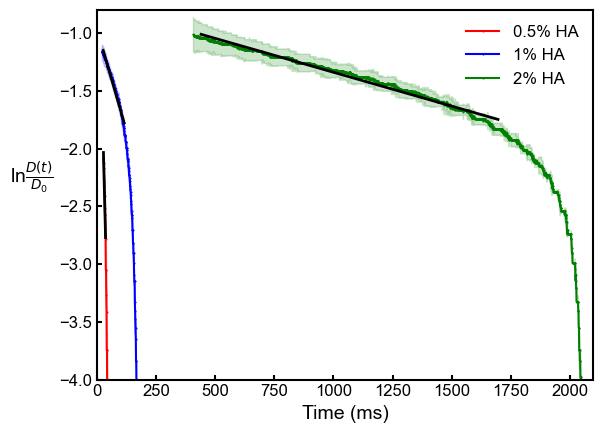

In [36]:
# FINALIZED to replot data with forward time

fig, ax = plt.subplots()

# Goal: calculate relaxation time, and generate graph - this is a very ineffecient way, and could work for small data sets! 

# Relevant equation: D(t)/D0 proportional to Ae^(-t/3*relaxation time -> ln(D(t)/D0)) = -t/3*relaxation time
# To calculate, want: slope of log/linear plot of D(t)/D0 vs (tc-t). Slope = 1/3*relaxation time --> relaxation time = 1/3*slope
## 1. Calculate ln(D(t)/D0) for each experiment

relax_expts = {} # dictionary to manage the dataframes with relevant data for relaxation time 
for i in range(3): # Going through each relevant experiment
# i = 0 # 0.5% HA
    df = averaged_tbreak_aligned[expts[i]]
    # column selection
    t_cols = [0, 3, 6] # columns corresponding to tc-t for each replicate
    d_cols = [2, 5, 8] # columns corresponding to d/do for each replicate
    for c in d_cols[:]: 
        df[f"ln(d/d0)_{d_cols.index(c)+1}"] = np.log(df.iloc[1:, c]) # caclulating lnd/do. each column has new title lnd/do_1 to lnd/do_3
    df["avgln(d/d0)"] = df.iloc[:, [15,16,17]].mean(axis=1) # mean of the ln(d/do)
    df["stdln(d/d0)"] = df.iloc[:, [15,16,17]].std(axis=1)  # standard deviation of ln(d/do)

    relax_df = df.iloc[:, [9,15,16,17,18, 19]].dropna() # Only keep data frame 
    relax_expts.update({expts[i]: relax_df})

### ----------- NEED TO DO FOR EACH DATA SET FROM HERE ON ---------------
# # 2. Determine linear region via second derivative analysis - using average 
i = 0 # 0.5% HA
# for i in range(3):
relax_df = relax_expts[expts[i]]
smooth_window = 7
relax_df["smooth_avglnd/do"] = savgol_filter(relax_df["avgln(d/d0)"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d1"] = np.gradient(relax_df["smooth_avglnd/do"], relax_df["avg_tc-t"]) # find first derivative
relax_df["smooth_d1"] = savgol_filter(relax_df["d1"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d2"] = np.gradient(relax_df["smooth_d1"], relax_df["avg_tc-t"]) # find second derivative
# relax_df["fwd tc-t"] = relax_df["avg_tc-t"].values[-1] - relax_df["avg_tc-t"]
relax_df["fwd tc-t"] = y_tbr[0] - relax_df["avg_tc-t"]

## 3. Determine linear region of log/linear plot ---> corresponds to exponential region of linear/linear plot
# find when d2 = 0 (i.e. <0.01)
mask = np.abs(relax_df["d2"].values[:]) < 0.015 # this helps identifiy the regions
start = relax_df["avg_tc-t"][mask].index[0] # find starting index for linear regression
end = relax_df["avg_tc-t"][mask].index[-1] # find final index for linear regression
## 4. Fit line (do linear regression) and extract slope on each individual dataset, and calculat relaxation time:
reps = 3
regr_data = [] # list of tuples with slope, intercept, r^2 
rel_times = [] # list of relaxation times 
for c in range(1,reps+1):
    slope, intercept, r_value, p_value, stderr = linregress(relax_df.iloc[:, 0].values[start:end], relax_df.iloc[:, c].values[start:end]) #ms
    regr_data.append((slope, intercept, r_value))
    rel_times.append(1/(3*slope))

avg_relax_t_05HA = sum(rel_times)/reps
stdev_relax_t_05HA= np.std(rel_times)
print("0.5%HA:", "r-square =", ((regr_data[0][2]+ regr_data[1][2] + regr_data[2][2])/3)**2, "lambda =", avg_relax_t_05HA, "+/-", stdev_relax_t_05HA)


# ax.plot(relax_df["avg_tc-t"][5:], relax_df["avgln(d/d0)"][5:], 
#         color = run_colours[expts[i]], label = label_names[expts[i]], marker = "o", markersize = 0.5, linestyle = "-")
# ax.fill_between(relax_df["avg_tc-t"], 
#                 relax_df["avgln(d/d0)"] + relax_df["stdln(d/d0)"], 
#                 relax_df["avgln(d/d0)"] - relax_df["stdln(d/d0)"], 
#                 alpha = 0.2, color = run_colours[expts[i]])
ax.plot(relax_df["fwd tc-t"][:], relax_df["avgln(d/d0)"][:], 
        color = run_colours[expts[i]], label = label_names[expts[i]], marker = "o", markersize = 0.5, linestyle = "-")
ax.fill_between(relax_df["fwd tc-t"], 
                relax_df["avgln(d/d0)"] + relax_df["stdln(d/d0)"], 
                relax_df["avgln(d/d0)"] - relax_df["stdln(d/d0)"], 
                alpha = 0.2, color = run_colours[expts[i]])
# ax.plot(relax_df["avg_tc-t"][start:end], relax_df["smooth_avglnd/do"][start:end])
# ax.plot(relax_df["avg_tc-t"], relax_df["d1"])
# ax.plot(relax_df["avg_tc-t"], relax_df["d2"])
# avg_slope = (regr_data[0][0]+ regr_data[1][0] + regr_data[2][0])/3
# avg_int = (regr_data[0][1]+ regr_data[1][1] + regr_data[2][1])/3
# ax.plot(relax_df["avg_tc-t"][start:end], avg_slope*relax_df["avg_tc-t"][start:end] + avg_int, 
#         color='black', linestyle='-', linewidth=2)
m, b, r, p, stde = linregress(relax_df.loc[:, "fwd tc-t"].values[start:end], relax_df.loc[:, "avgln(d/d0)"].values[start:end]) #ms

ax.plot(relax_df["fwd tc-t"][start:end], m*relax_df["fwd tc-t"][start:end] + b, 
        color='black', linestyle='-', linewidth=2)
#----------------------------------------------------------------------------------------------------------------------------#
i = 1 # 1% HA

relax_df = relax_expts[expts[i]]
smooth_window = 17
relax_df["smooth_avglnd/do"] = savgol_filter(relax_df["avgln(d/d0)"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d1"] = np.gradient(relax_df["smooth_avglnd/do"], relax_df["avg_tc-t"]) # find first derivative
relax_df["smooth_d1"] = savgol_filter(relax_df["d1"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d2"] = np.gradient(relax_df["smooth_d1"], relax_df["avg_tc-t"]) # find second derivative
# relax_df["fwd tc-t"] = relax_df["avg_tc-t"].values[-1] - relax_df["avg_tc-t"]
relax_df["fwd tc-t"] = y_tbr[1] - relax_df["avg_tc-t"]

## 3. Determine linear region of log/linear plot ---> corresponds to exponential region of linear/linear plot
# find when d2 = 0 (i.e. <0.01)
mask = np.abs(relax_df["d2"].values[:]) < 0.00015 # this helps identifiy the regions
start = relax_df["avg_tc-t"][mask].index[0] # find starting index for linear regression
end = relax_df["avg_tc-t"][mask].index[-1] # find final index for linear regression
## 4. Fit line (do linear regression) and extract slope on each individual dataset, and calculat relaxation time:
reps = 3
regr_data = [] # list of tuples with slope, intercept, r^2 
rel_times = [] # list of relaxation times 
for c in range(1,reps+1):
    slope, intercept, r_value, p_value, stderr = linregress(relax_df.iloc[:, 0].values[start:end], relax_df.iloc[:, c].values[start:end]) #ms
    regr_data.append((slope, intercept, r_value))
    rel_times.append(1/(3*slope))
avg_relax_t_1HA = sum(rel_times)/reps
stdev_relax_t_1HA= np.std(rel_times)
print("1%HA:", "r-square =", ((regr_data[0][2]+ regr_data[1][2] + regr_data[2][2])/3)**2, "lambda =", avg_relax_t_1HA, "+/-", stdev_relax_t_1HA)

        # plotting
# ax.plot(relax_df["avg_tc-t"][5:], relax_df["avgln(d/d0)"][5:], 
#         color = run_colours[expts[i]], label = label_names[expts[i]], marker = "o", markersize = 0.5, linestyle = "-")
# ax.fill_between(relax_df["avg_tc-t"], 
#                 relax_df["avgln(d/d0)"] + relax_df["stdln(d/d0)"], 
#                 relax_df["avgln(d/d0)"] - relax_df["stdln(d/d0)"], 
#                 alpha = 0.2, color = run_colours[expts[i]])
ax.plot(relax_df["fwd tc-t"][:], relax_df["avgln(d/d0)"][:], 
        color = run_colours[expts[i]], label = label_names[expts[i]], marker = "o", markersize = 0.5, linestyle = "-")
ax.fill_between(relax_df["fwd tc-t"], 
                relax_df["avgln(d/d0)"] + relax_df["stdln(d/d0)"], 
                relax_df["avgln(d/d0)"] - relax_df["stdln(d/d0)"], 
                alpha = 0.2, color = run_colours[expts[i]])

# avg_slope = (regr_data[0][0]+ regr_data[1][0] + regr_data[2][0])/3
# avg_int = (regr_data[0][1]+ regr_data[1][1] + regr_data[2][1])/3
# ax.plot(relax_df["avg_tc-t"][start:end], avg_slope*relax_df["avg_tc-t"][start:end] + avg_int, 
#         color='black', linestyle='-', linewidth=2)
m, b, r, p, stde = linregress(relax_df.loc[:, "fwd tc-t"].values[start:end], relax_df.loc[:, "avgln(d/d0)"].values[start:end]) #ms

ax.plot(relax_df["fwd tc-t"][start:end], m*relax_df["fwd tc-t"][start:end] + b, 
        color='black', linestyle='-', linewidth=2)

#----------------------------------------------------------------------------------------------------------------------------#
i = 2 # 2% HA

relax_df = relax_expts[expts[i]]
smooth_window = 51
relax_df["smooth_avglnd/do"] = savgol_filter(relax_df["avgln(d/d0)"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d1"] = np.gradient(relax_df["smooth_avglnd/do"], relax_df["avg_tc-t"]) # find first derivative
relax_df["smooth_d1"] = savgol_filter(relax_df["d1"], window_length=smooth_window, polyorder=3)  # smoothing using savitzky golay
relax_df["d2"] = np.gradient(relax_df["smooth_d1"], relax_df["avg_tc-t"]) # find second derivative
# relax_df["fwd tc-t"] = relax_df["avg_tc-t"].values[-1] - relax_df["avg_tc-t"]
relax_df["fwd tc-t"] = y_tbr[2] - relax_df["avg_tc-t"]


## 3. Determine linear region of log/linear plot ---> corresponds to exponential region of linear/linear plot
# find when d2 = 0 (i.e. <0.01)
mask = np.abs(relax_df["d2"].values[:]) < 0.0000009 # this helps identifiy the regions
start = relax_df["avg_tc-t"][mask].index[0] # find starting index for linear regression
end = relax_df["avg_tc-t"][mask].index[-1] # find final index for linear regression
## 4. Fit line (do linear regression) and extract slope on each individual dataset, and calculat relaxation time:
reps = 3
regr_data = [] # list of tuples with slope, intercept, r^2 
rel_times = [] # list of relaxation times 
for c in range(1,reps+1):
    slope, intercept, r_value, p_value, stderr = linregress(relax_df.iloc[:, 0].values[start:end], relax_df.iloc[:, c].values[start:end]) #ms
    regr_data.append((slope, intercept, r_value))
    rel_times.append(1/(3*slope))
avg_relax_t_2HA = sum(rel_times)/reps
stdev_relax_t_2HA= np.std(rel_times)
print("2%HA:", "r-square =", ((regr_data[0][2]+ regr_data[1][2] + regr_data[2][2])/3)**2, "lambda =", avg_relax_t_2HA, "+/-", stdev_relax_t_2HA)

        # plotting
# ax.plot(relax_df["avg_tc-t"][5:], relax_df["avgln(d/d0)"][5:], 
#         color = run_colours[expts[i]], label = label_names[expts[i]], marker = "o", markersize = 0.5, linestyle = "-")
# ax.fill_between(relax_df["avg_tc-t"][5:], 
#                 relax_df["avgln(d/d0)"][5:] + relax_df["stdln(d/d0)"][5:], 
#                 relax_df["avgln(d/d0)"][5:] - relax_df["stdln(d/d0)"][5:], 
#                 alpha = 0.2, color = run_colours[expts[i]])
ax.plot(relax_df["fwd tc-t"][:], relax_df["avgln(d/d0)"][:], 
        color = run_colours[expts[i]], label = label_names[expts[i]], marker = "o", markersize = 0.5, linestyle = "-")
ax.fill_between(relax_df["fwd tc-t"], 
                relax_df["avgln(d/d0)"] + relax_df["stdln(d/d0)"], 
                relax_df["avgln(d/d0)"] - relax_df["stdln(d/d0)"], 
                alpha = 0.2, color = run_colours[expts[i]])

# avg_slope = (regr_data[0][0]+ regr_data[1][0] + regr_data[2][0])/3
# avg_int = (regr_data[0][1]+ regr_data[1][1] + regr_data[2][1])/3
# ax.plot(relax_df["avg_tc-t"][start:end], avg_slope*relax_df["avg_tc-t"][start:end] + avg_int, 
#         color='black', linestyle='-', linewidth=2)

m, b, r, p, stde = linregress(relax_df.loc[:, "fwd tc-t"].values[start:end], relax_df.loc[:, "avgln(d/d0)"].values[start:end]) #ms

ax.plot(relax_df["fwd tc-t"][start:end], m*relax_df["fwd tc-t"][start:end] + b, 
        color='black', linestyle='-', linewidth=2)


# ax.set_xlabel(r"Time to breakup, $t_c$-t (ms)", fontsize = 14)
ax.set_xlabel(r"Time (ms)", fontsize = 14)
ax.set_ylabel(r"ln$\frac{D(t)}{D_0}$", fontsize = 14, rotation = 0, labelpad=20, ha = "center")
ax.legend(frameon = False, fontsize = 12)
ax.tick_params(axis='both', labelsize=12, width = 1.5, direction = "in")
# ax.legend(frameon = False)
# plt.xscale("log")
plt.xlim(0, 2100)
plt.ylim(-4, -0.8)
# relax_df
# 
# plt.savefig(fr"{parent_folder}\HA_concentrations_fwd_time_V2.png", dpi=300, bbox_inches='tight', transparent = True) 